# Extract Climate Data — Rakičan

Extracts daily point timeseries from EURO-CORDEX NetCDF files for Rakičan and summarises statistics by 30-year period.

NetCDF source files (historical, rcp26, rcp45, rcp85) are in data/external/climate. Outputs go to data/interim/climate. Interim files are then ingested to produce final pickle files ready for aquacrop

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from aquacrop_slovenia import config
from aquacrop_slovenia.climate_data import extract_all_timeseries, prepare_climate_data
from aquacrop_slovenia.plots import load_all_timeseries, plot_all_timeseries, plot_grid_points, plot_all_period_statistics
from IPython.display import display
from loguru import logger
import calendar
import pandas as pd
import sys

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


## Rakičan

In [3]:
LOCATION_NAME = "rakican"
TARGET_LAT = 46.650
TARGET_LON = 16.196

2026-06-23 00:00:16.589 | INFO     | aquacrop_slovenia.plots:plot_grid_points:74 - Nearest grid cell: lat=46.6875, lon=16.1875


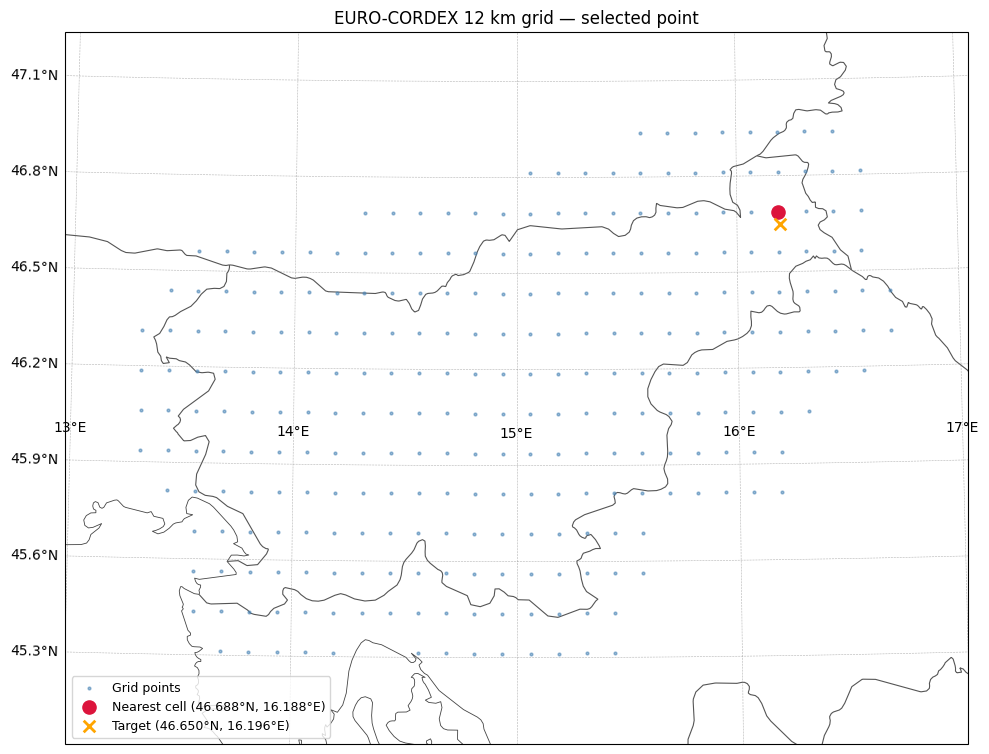

In [4]:
fig = plot_grid_points(TARGET_LAT, TARGET_LON)
fig.tight_layout()

In [5]:
extract_all_timeseries(TARGET_LAT, TARGET_LON, location_name=LOCATION_NAME)
print(f"CSVs written to: {config.INTERIM_CLIMATE_DIR}")

2026-06-23 00:00:17.713 | INFO     | aquacrop_slovenia.climate_data:discover_files:76 - Discovered 285 NetCDF files in C:\Users\rokuk\Documents\Code\aquacrop-slovenia\data\external\climate
2026-06-23 00:00:17.714 | INFO     | aquacrop_slovenia.climate_data:extract_all_timeseries:212 - Found 15 model/scenario groups, 6 RCM models
2026-06-23 00:00:17.718 | INFO     | aquacrop_slovenia.climate_data:extract_all_timeseries:222 - Saved model_mapping.csv (7 entries)


Extracting timeseries:   0%|          | 0/15 [00:00<?, ?it/s]

2026-06-23 00:00:17.721 | INFO     | aquacrop_slovenia.climate_data:extract_all_timeseries:232 - Processing obs (ARSO / obs) / hist
2026-06-23 00:00:17.739 | DEBUG    | aquacrop_slovenia.climate_data:extract_group:164 - Nearest cell: lat=46.6875, lon=16.1875 (target: 46.6500, 16.1960)
2026-06-23 00:00:18.328 | DEBUG    | aquacrop_slovenia.climate_data:extract_all_timeseries:246 - Saved rakican_obs_hist.csv (10957 rows)


Extracting timeseries:   7%|▋         | 1/15 [00:00<00:08,  1.65it/s]

2026-06-23 00:00:18.328 | INFO     | aquacrop_slovenia.climate_data:extract_all_timeseries:232 - Processing model2 (ICHEC-EC-EARTH / DMI-HIRHAM5) / rcp26
2026-06-23 00:00:18.404 | DEBUG    | aquacrop_slovenia.climate_data:extract_group:164 - Nearest cell: lat=46.6875, lon=16.1875 (target: 46.6500, 16.1960)
2026-06-23 00:00:20.849 | DEBUG    | aquacrop_slovenia.climate_data:extract_all_timeseries:246 - Saved rakican_model2_rcp26.csv (43800 rows)


...

Extracting timeseries:  87%|████████▋ | 13/15 [00:31<00:05,  2.55s/it]

2026-06-23 00:00:49.227 | INFO     | aquacrop_slovenia.climate_data:extract_all_timeseries:232 - Processing model5 (MPI-M-MPI-ESM-LR / CLMcom-CCLM4-8-17) / rcp85
2026-06-23 00:00:49.297 | DEBUG    | aquacrop_slovenia.climate_data:extract_group:164 - Nearest cell: lat=46.6875, lon=16.1875 (target: 46.6500, 16.1960)
2026-06-23 00:00:51.867 | DEBUG    | aquacrop_slovenia.climate_data:extract_all_timeseries:246 - Saved rakican_model5_rcp85.csv (43800 rows)


Extracting timeseries:  93%|█████████▎| 14/15 [00:34<00:02,  2.57s/it]

2026-06-23 00:00:51.868 | INFO     | aquacrop_slovenia.climate_data:extract_all_timeseries:232 - Processing model6 (MPI-M-MPI-ESM-LR / SMHI-RCA4) / rcp85
2026-06-23 00:00:51.941 | DEBUG    | aquacrop_slovenia.climate_data:extract_group:164 - Nearest cell: lat=46.6875, lon=16.1875 (target: 46.6500, 16.1960)
2026-06-23 00:00:54.370 | DEBUG    | aquacrop_slovenia.climate_data:extract_all_timeseries:246 - Saved rakican_model6_rcp85.csv (43800 rows)


Extracting timeseries: 100%|██████████| 15/15 [00:36<00:00,  2.44s/it]
CSVs written to: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\data\interim\climate


## Preparing data for aquacrop

Loads the interim files and prepare the data so it has correct units and form to be used when calling Aquacrop. The data is then saved in the processed folder in pickle files.

In [6]:
prepare_climate_data(LOCATION_NAME)
print(f"Pickles written to: {config.PROCESSED_CLIMATE_DIR}")

2026-06-23 00:00:54.456 | INFO     | aquacrop_slovenia.climate_data:prepare_climate_data:253 - Preparing climate data for rakican with model1 and rcp45
2026-06-23 00:00:54.504 | DEBUG    | aquacrop_slovenia.climate_data:prepare_climate_data:264 - Saved rakican_model1_rcp45.pkl
2026-06-23 00:00:54.505 | INFO     | aquacrop_slovenia.climate_data:prepare_climate_data:253 - Preparing climate data for rakican with model1 and rcp85
2026-06-23 00:00:54.563 | DEBUG    | aquacrop_slovenia.climate_data:prepare_climate_data:264 - Saved rakican_model1_rcp85.pkl
2026-06-23 00:00:54.563 | INFO     | aquacrop_slovenia.climate_data:prepare_climate_data:253 - Preparing climate data for rakican with model2 and rcp26
2026-06-23 00:00:54.607 | DEBUG    | aquacrop_slovenia.climate_data:prepare_climate_data:264 - Saved rakican_model2_rcp26.pkl
2026-06-23 00:00:54.607 | INFO     | aquacrop_slovenia.climate_data:prepare_climate_data:253 - Preparing climate data for rakican with model2 and rcp45
2026-06-23 00:

Pickles written to: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\data\processed\climate


## Model mapping ids

In [7]:
# Model mapping table
mapping = pd.read_csv(config.INTERIM_CLIMATE_DIR / "model_mapping.csv")
display(mapping)

sample = pd.read_csv(
    config.INTERIM_CLIMATE_DIR / f"{LOCATION_NAME}_obs_hist.csv", index_col=0, parse_dates=True
)
sample.head()

,short_name,gcm,rcm
0,obs,ARSO,NaN
1,model1,CNRM-CERFACS-CNRM-CM5,CLMcom-CCLM4-8-17
2,model2,ICHEC-EC-EARTH,DMI-HIRHAM5
3,model3,IPSL-IPSL-CM5A-MR,IPSL-INERIS-WRF331F
4,model4,MOHC-HadGEM2-ES,KNMI-RACMO22E
5,model5,MPI-M-MPI-ESM-LR,CLMcom-CCLM4-8-17
6,model6,MPI-M-MPI-ESM-LR,SMHI-RCA4


,pr,tas,tasmax,tasmin,evspsblpot
time,,,,,
1981-01-01,0.000000,271.86038,274.03800,266.24090,0.000003
1981-01-02,0.000000,274.61023,279.12357,270.86423,0.000006
1981-01-03,0.000000,279.41614,281.96597,272.68982,0.000017
1981-01-04,0.000000,276.26750,281.37607,272.44754,0.000005
1981-01-05,0.000074,273.64360,276.72842,272.06378,0.000011


In [8]:
sample.describe()

,pr,tas,tasmax,tasmin,evspsblpot
count,10957.000000,10957.000000,10957.000000,10957.000000,10957.000000
mean,0.000025,283.406906,288.632515,278.489553,0.000024
std,0.000066,8.444164,9.554565,7.727134,0.000019
min,0.000000,254.969380,260.531250,247.958250,0.000000
25%,0.000000,276.561680,280.980800,272.556700,0.000007
50%,0.000000,284.201540,289.623660,278.997860,0.000020
75%,0.000013,290.362030,296.370150,285.010650,0.000039
max,0.000881,301.678380,311.566530,294.977300,0.000094


## Climate projection visualizations

In [9]:
df = load_all_timeseries(LOCATION_NAME)
print(df.columns.get_level_values("model").unique().tolist())
df.head()

2026-06-23 00:00:56.280 | INFO     | aquacrop_slovenia.plots:load_all_timeseries:198 - Loaded 15 timeseries files for 'rakican'


['model1', 'model2', 'model3', 'model4', 'model5', 'model6', 'obs']


model         model1                                                     \
scenario       rcp45                                              rcp85   
variable          pr     tas     tasmax     tasmin evspsblpot        pr   
date                                                                      
1981-01-01  0.000000  272.43  274.76978  268.99980   0.000001  0.000000   
1981-01-02  0.000014  274.23  274.67130  273.83130   0.000003  0.000013   
1981-01-03  0.000089  271.42  272.25760  269.30760   0.000002  0.000089   
1981-01-04  0.000000  268.45  272.85468  265.84467   0.000002  0.000000   
1981-01-05  0.000000  268.50  276.27417  261.53418   0.000002  0.000000   

model                                                ...        model6  \
scenario                                             ...         rcp85   
variable       tas     tasmax     tasmin evspsblpot  ...            pr   
date                                                 ...                 
1981-01-01  272.25  274.54977  268.82980   0.000001  ...  0.000000e+00   
1981-01-02  274.03  274.44128  273.62128   0.000002  ...  0.000000e+00   
1981-01-03  271.78  272.63757  270.08760   0.000002  ...  0.000000e+00   
1981-01-04  268.46  272.89465  265.77463   0.000002  ...  1.822421e-07   
1981-01-05  268.60  277.14420  261.79420   0.000002  ...  0.000000e+00   

model                                                     obs             \
scenario                                                 hist              
variable       tas     tasmax     tasmin evspsblpot        pr        tas   
date                                                                       
1981-01-01  267.24  267.98700  266.81702   0.000010  0.000000  271.86038   
1981-01-02  267.88  269.39220  265.08220   0.000007  0.000000  274.61023   
1981-01-03  269.15  271.22318  267.50317   0.000005  0.000000  279.41614   
1981-01-04  270.01  275.21740  266.23740   0.000004  0.000000  276.26750   
1981-01-05  271.78  273.10190  269.11190   0.000004  0.000074  273.64360   

model                                        
scenario                                     
variable       tasmax     tasmin evspsblpot  
date                                         
1981-01-01  274.03800  266.24090   0.000003  
1981-01-02  279.12357  270.86423   0.000006  
1981-01-03  281.96597  272.68982   0.000017  
1981-01-04  281.37607  272.44754   0.000005  
1981-01-05  276.72842  272.06378   0.000011  

[5 rows x 75 columns]

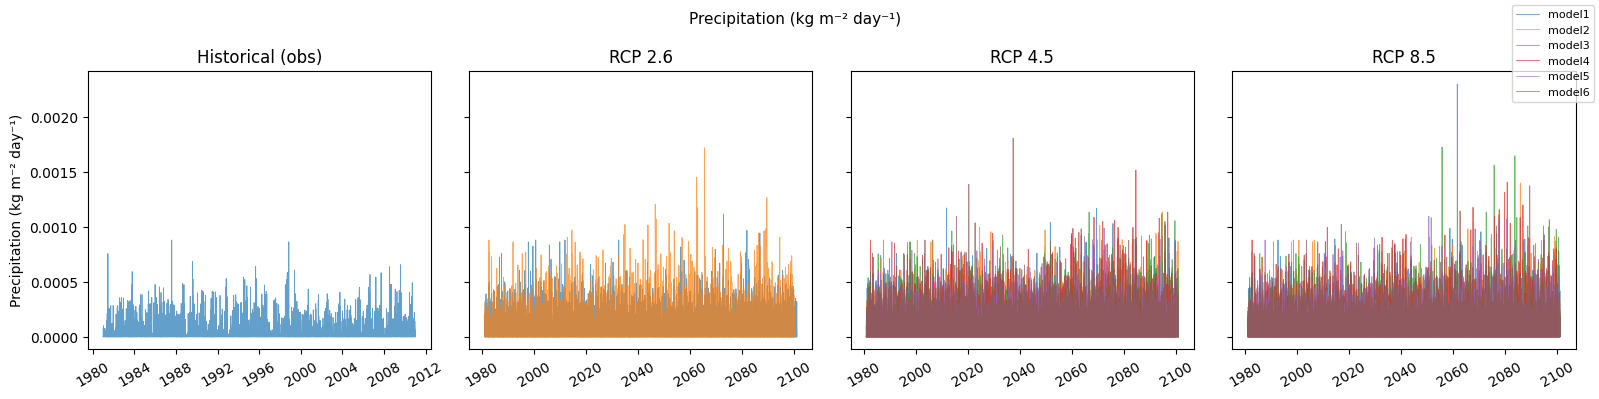

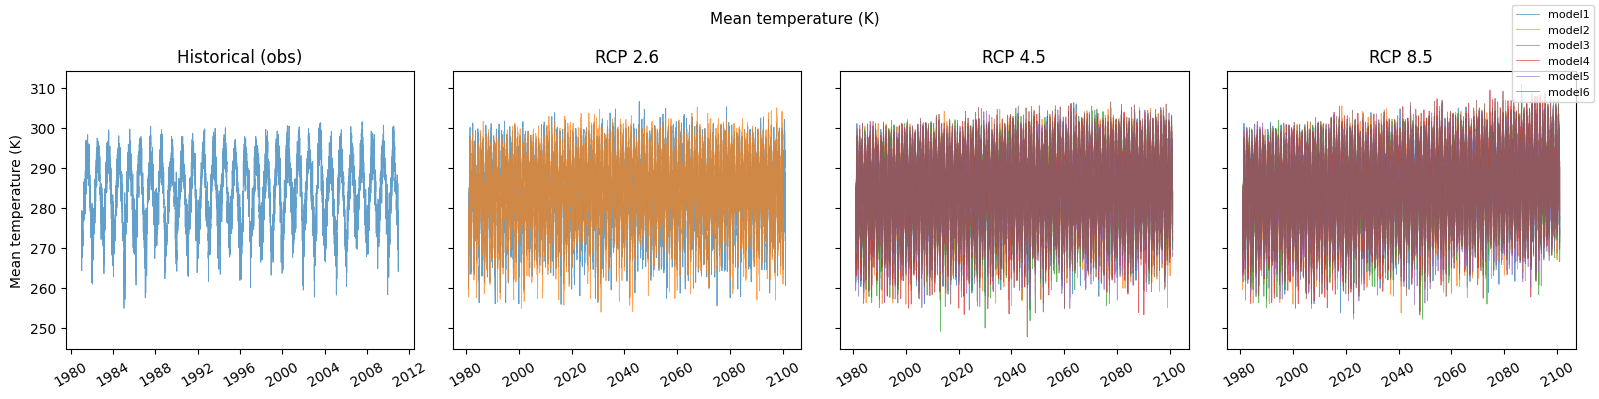

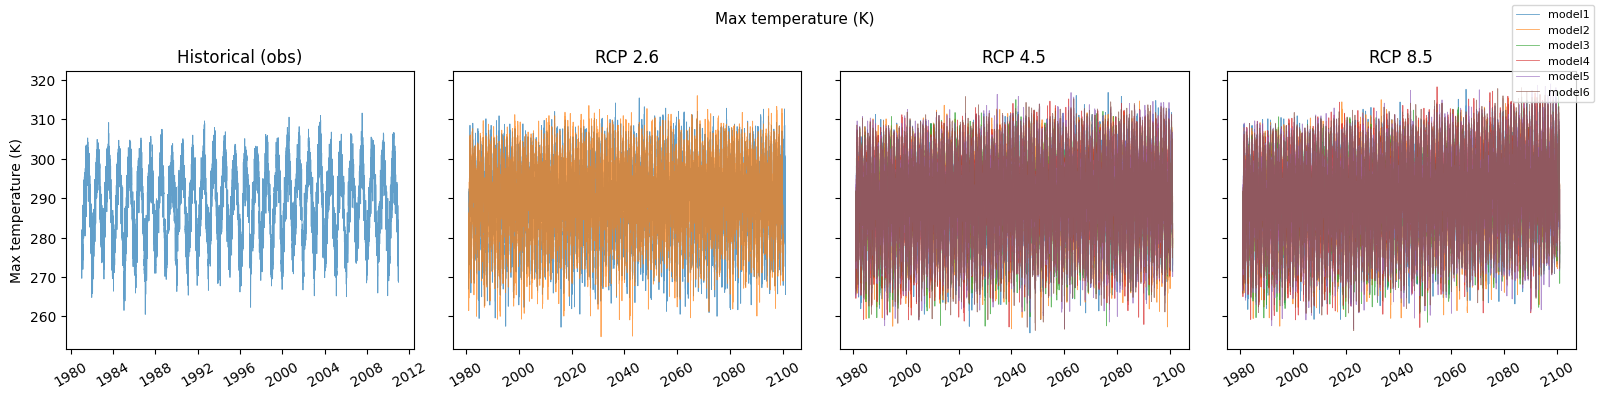

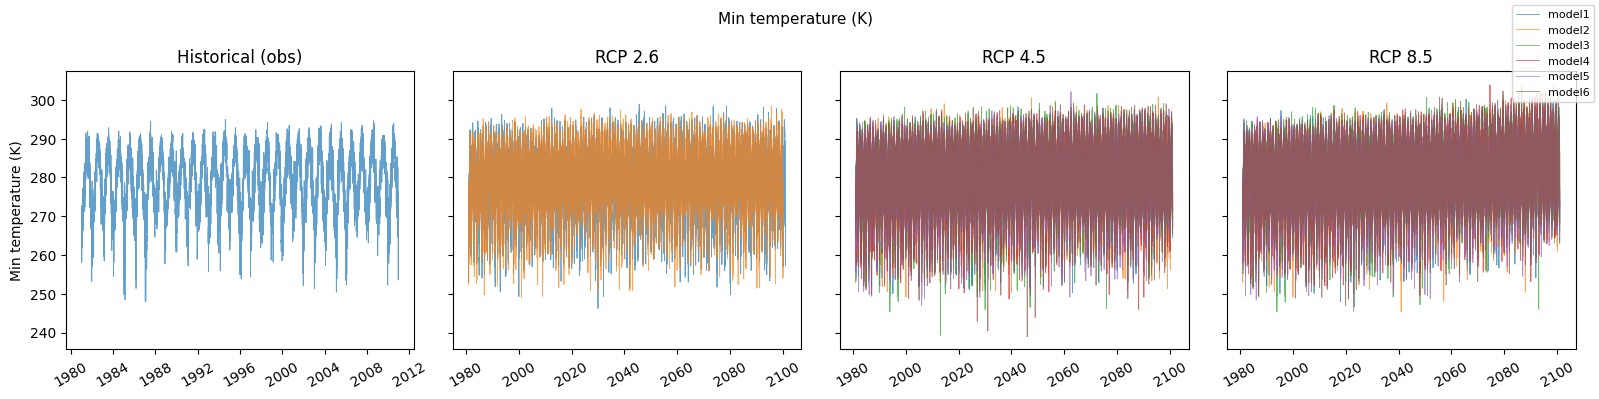

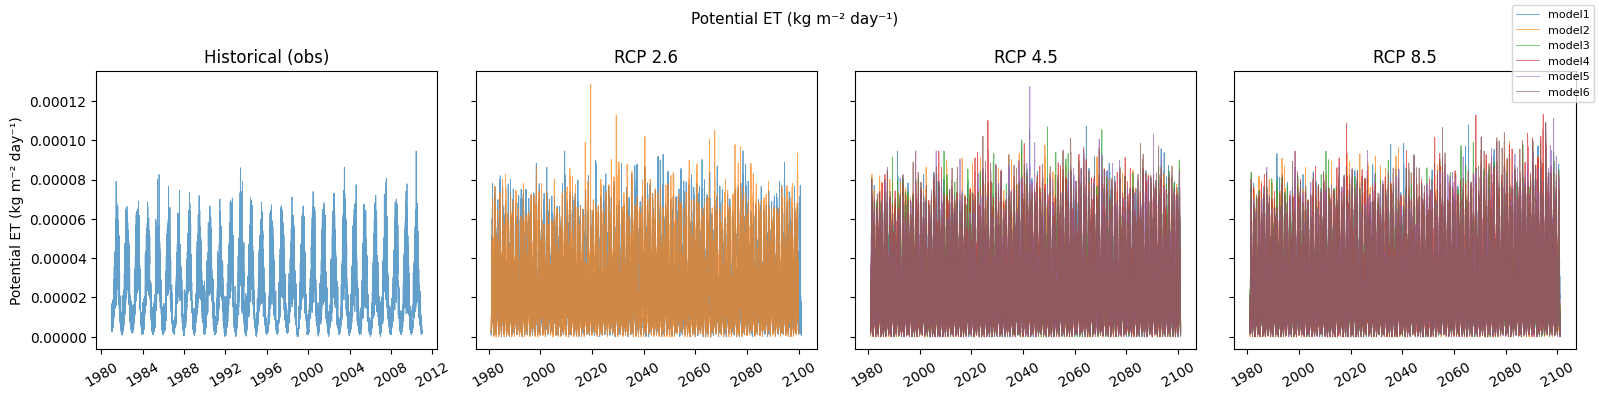

In [10]:
figs = plot_all_timeseries(df)

## Climate projection statistics

Monthly climatology and yearly summary statistics (mean, min, max) for each variable, model and scenario, split into 30-year periods. Temperatures converted to °C.

In [11]:
MONTH_ABBR = [calendar.month_abbr[m] for m in range(1, 13)]

PERIODS = ["1981-2010", "2011-2040", "2041-2070", "2071-2100"]
_PERIOD_BINS = [1980, 2010, 2040, 2070, 2100]
TEMP_VARS = {"tas", "tasmax", "tasmin"}

long = df.stack(level=["model", "scenario"]).copy()
for var in TEMP_VARS:
    if var in long.columns:
        long[var] -= 273.15

date_idx = long.index.get_level_values("date")
model_idx = long.index.get_level_values("model")
scen_idx = long.index.get_level_values("scenario")
period_cat = pd.cut(date_idx.year, bins=_PERIOD_BINS, labels=PERIODS)

monthly_clim = long.groupby([period_cat, scen_idx, model_idx, date_idx.month]).mean()
monthly_clim.index.names = ["period", "scenario", "model", "month"]
monthly_clim = monthly_clim.rename(
    index={i: MONTH_ABBR[i - 1] for i in range(1, 13)}, level="month"
)

yearly = long.groupby([period_cat, scen_idx, model_idx, date_idx.year]).mean()
yearly.index.names = ["period", "scenario", "model", "year"]
yearly_summary = yearly.groupby(level=["period", "scenario", "model"]).agg(["mean", "min", "max"])

print(f"Monthly climatology shape: {monthly_clim.shape}")
print(f"Yearly summary shape:      {yearly_summary.shape}")

C:\Users\rokuk\AppData\Local\Temp\ipykernel_79572\4138331356.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long = df.stack(level=["model", "scenario"]).copy()
C:\Users\rokuk\AppData\Local\Temp\ipykernel_79572\4138331356.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = val

Monthly climatology shape: (1344, 5)
Yearly summary shape:      (112, 15)


C:\Users\rokuk\AppData\Local\Temp\ipykernel_79572\4138331356.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_clim = long.groupby([period_cat, scen_idx, model_idx, date_idx.month]).mean()
C:\Users\rokuk\AppData\Local\Temp\ipykernel_79572\4138331356.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly = long.groupby([period_cat, scen_idx, model_idx, date_idx.year]).mean()
C:\Users\rokuk\AppData\Local\Temp\ipykernel_79572\4138331356.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current

In [12]:
VARIABLE_LABELS = {
    "pr": "Precipitation (kg m⁻² day⁻¹)",
    "tas": "Mean temperature (°C)",
    "tasmax": "Max temperature (°C)",
    "tasmin": "Min temperature (°C)",
    "evspsblpot": "Potential ET (kg m⁻² day⁻¹)",
}
_caption_style = [{"selector": "caption", "props": "font-weight: bold; font-size: 1.1em; text-align: left;"}]
_month_order = {m: i for i, m in enumerate(MONTH_ABBR)}

print("=== Monthly Climatology ===")
for var in monthly_clim.columns:
    tbl = monthly_clim[var].unstack("period")
    tbl = tbl.reorder_levels(["month", "model", "scenario"])
    tbl = tbl.sort_index(level="month", sort_remaining=False,
                         key=lambda idx: idx.map(_month_order))
    display(tbl.style.format("{:.4g}").set_caption(VARIABLE_LABELS.get(var, var)).set_table_styles(_caption_style))

=== Monthly Climatology ===


In [13]:
print("=== Yearly Statistics (mean / min / max of annual means) ===")
for var in yearly_summary.columns.get_level_values(0).unique():
    display(
        yearly_summary[var].style
        .format("{:.5g}")
        .set_caption(VARIABLE_LABELS.get(var, var))
        .set_table_styles(_caption_style)
    )

=== Yearly Statistics (mean / min / max of annual means) ===


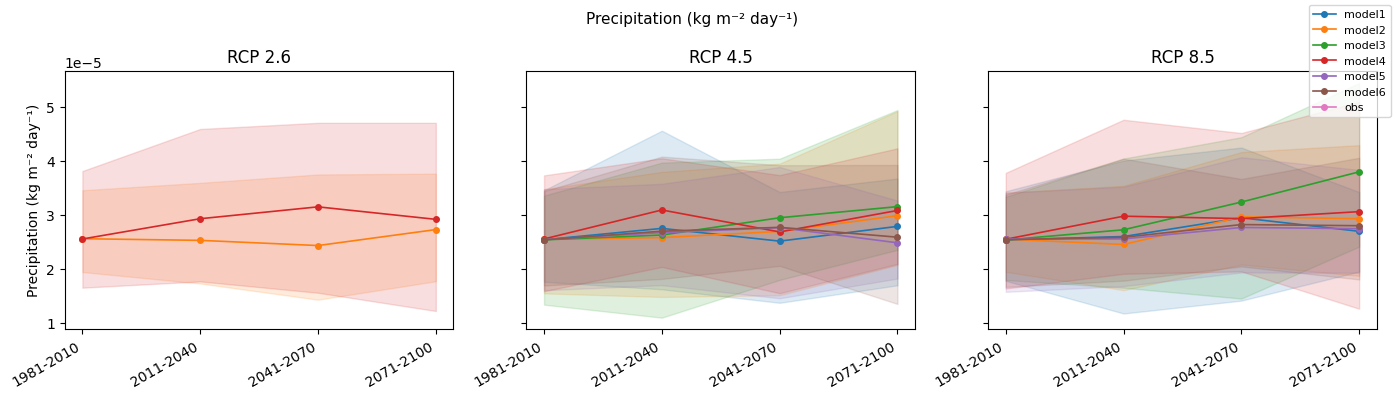

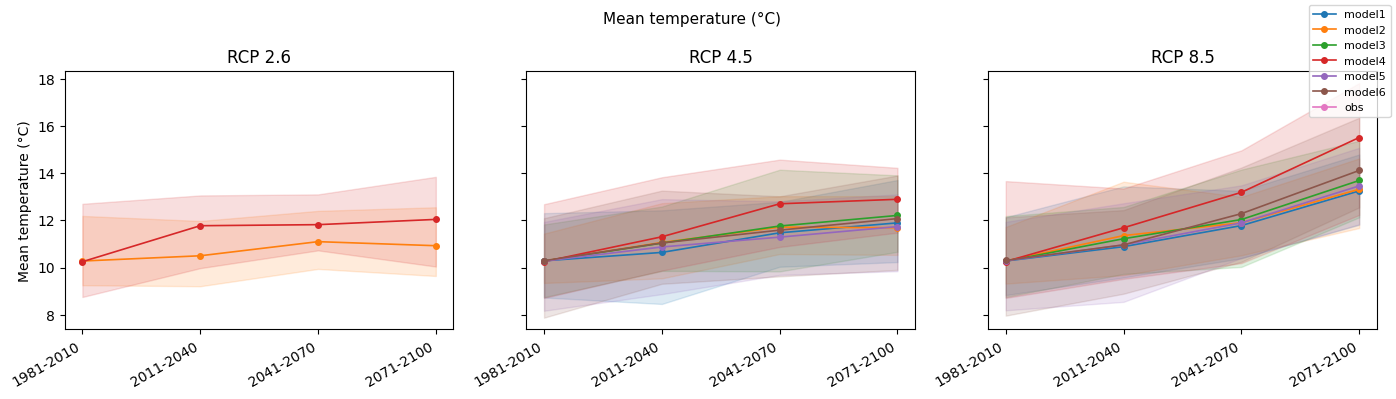

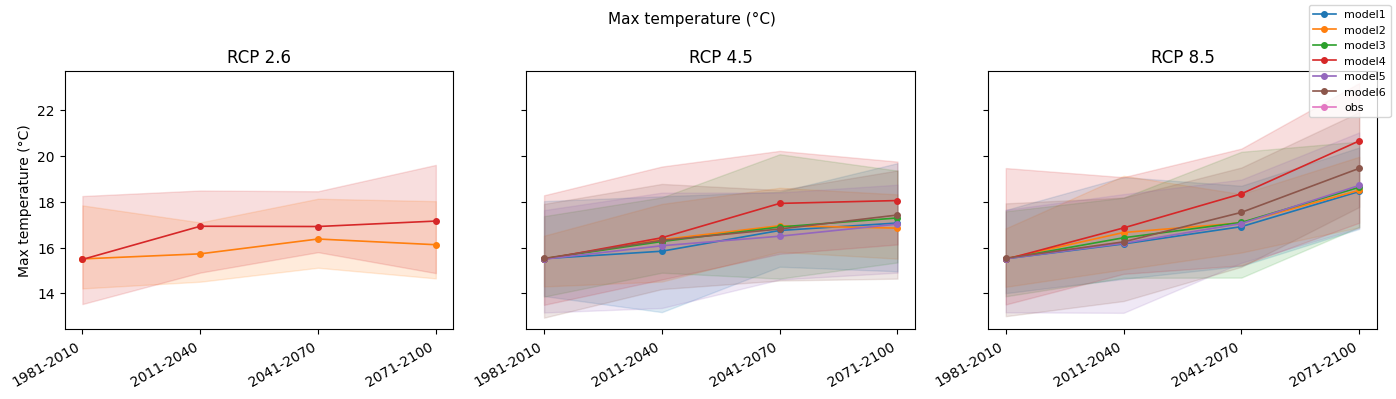

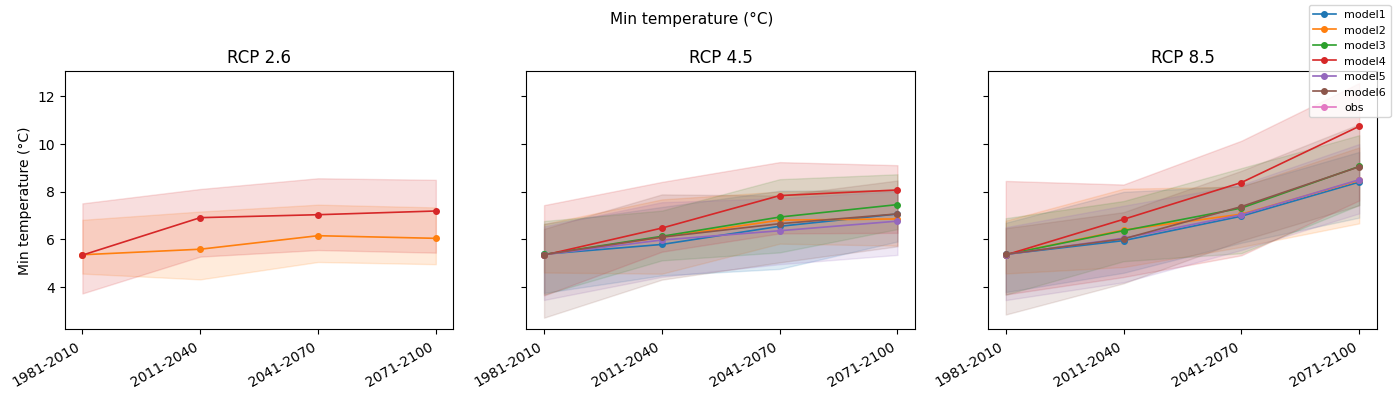

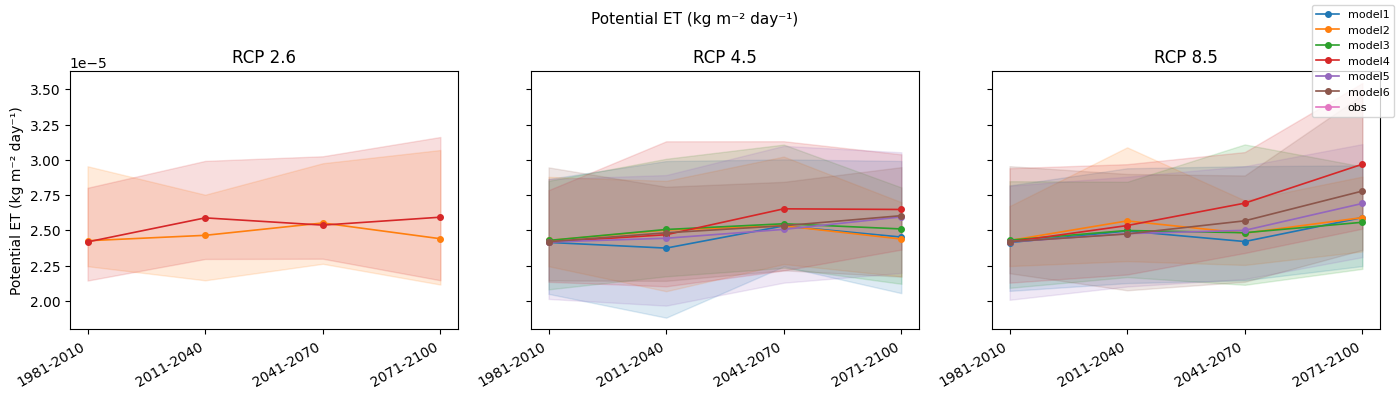

In [14]:
figs = plot_all_period_statistics(yearly_summary)